# Example Workflow: Community Detection on Cora
This pipeline demonstrates how to use the `majority_label_propagation` function to discover natural groupings within the Cora Citation Network purely from the structure of citations.

## 1. Data Preparation
The first step is to convert the raw data into a NetworkX graph object that the function can accept.

**Load Structure:** We read the citation list to build the graph structure. Each paper becomes a node, and a citation becomes an edge linking them.

**Load Metadata (Optional):** While not used for the algorithm itself, we load the actual paper topics (ground truth) to verify our results later.

**Pruning:** We remove isolated nodes (papers with no citations), as label propagation relies entirely on connectivity to function.

## 2. Initialization for Discovery
To perform unsupervised community detection (clustering) rather than classification, we set the initial state specifically to allow natural groups to emerge.

**Unique Labels:** Instead of pre-labeling a few "seed" nodes, we assign every single node a unique ID as its starting label.

**Concept:** This tells the algorithm that every node starts as its own independent community.

## 3. Execution
We call the `majority_label_propagation` function with the specific parameters for this unsupervised mode.

**freeze_seeds=False:** This is the critical setting. We allow all labels to change. As the algorithm runs, individual unique labels will die out as nodes adopt the labels of their neighbors, causing small communities to merge into larger ones.

**Convergence:** The function iterates until the network stabilizes and communities stop merging.

## 4. Visualization and Analysis
Once the function returns the labeled graph, we analyze the output.

**Filtering:** We identify the largest unique labels remaining in the graph. These represent the discovered communities.

**Visualizing:** We plot the graph using a force-directed layout, coloring nodes based on the community label assigned by the algorithm.

**Verification:** By checking the “Ground Truth” of the nodes inside a discovered cluster, we can confirm if the algorithm successfully grouped papers by topic (e.g., finding that Cluster A is mostly “Neural Networks” papers).

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
import tarfile
import random
from collections import Counter

random.seed(42)
np.random.seed(42)

In [3]:
# 1. Download
if not os.path.exists("cora"):
    print("Downloading Cora...")
    url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
    response = requests.get(url)
    with open("cora.tgz", "wb") as f:
        f.write(response.content)
    with tarfile.open("cora.tgz", "r:gz") as tar:
        tar.extractall(path=".")
        
# 2. Construct Graph
data_dir = "cora"
cites_path = os.path.join(data_dir, "cora.cites")
content_path = os.path.join(data_dir, "cora.content")

# Load Edges
edges = pd.read_csv(cites_path, sep='\t', header=None, names=["target", "source"])
G = nx.from_pandas_edgelist(edges, source="source", target="target")

# Load Ground Truth (Just for comparison later, NOT for training)
content = pd.read_csv(content_path, sep='\t', header=None)
ground_truth = dict(zip(content[0], content[1434]))

# Add ground truth attribute for reference
for node in G.nodes():
    if node in ground_truth:
        G.nodes[node]['ground_truth'] = ground_truth[node]

# Remove isolates
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Graph Ready: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph Ready: 2708 nodes, 5278 edges


In [4]:
# Initialize every node with a unique label (its own ID)
for node in G.nodes():
    G.nodes[node]['community'] = node 

print("Initialized unique labels for all nodes.")

Initialized unique labels for all nodes.


In [5]:
from ml.unsupervised_learning.graph_data.community_detection.majority_label_propogation import majority_label_propagation


print("--- Running Unsupervised Community Detection ---")
G = majority_label_propagation(G, label_attr='community', max_iter=100, freeze_seeds=False)

--- Running Unsupervised Community Detection ---


In [6]:
# Extract final communities
final_labels = nx.get_node_attributes(G, 'community')
communities = Counter(final_labels.values())

print(f"Total Communities Found: {len(communities)}")
print(f"Top 10 Largest Communities (Label: Size):")
print(communities.most_common(10))

# Filter out tiny communities (noise) for visualization
major_communities = {lbl for lbl, count in communities.items() if count > 10}
print(f"\nNumber of 'Major' Communities (>10 nodes): {len(major_communities)}")

Total Communities Found: 238
Top 10 Largest Communities (Label: Size):
[(35, 352), (28202, 182), (3231, 119), (1365, 93), (12350, 59), (3229, 55), (906, 48), (16819, 46), (2440, 39), (2658, 38)]

Number of 'Major' Communities (>10 nodes): 57


Calculating layout...


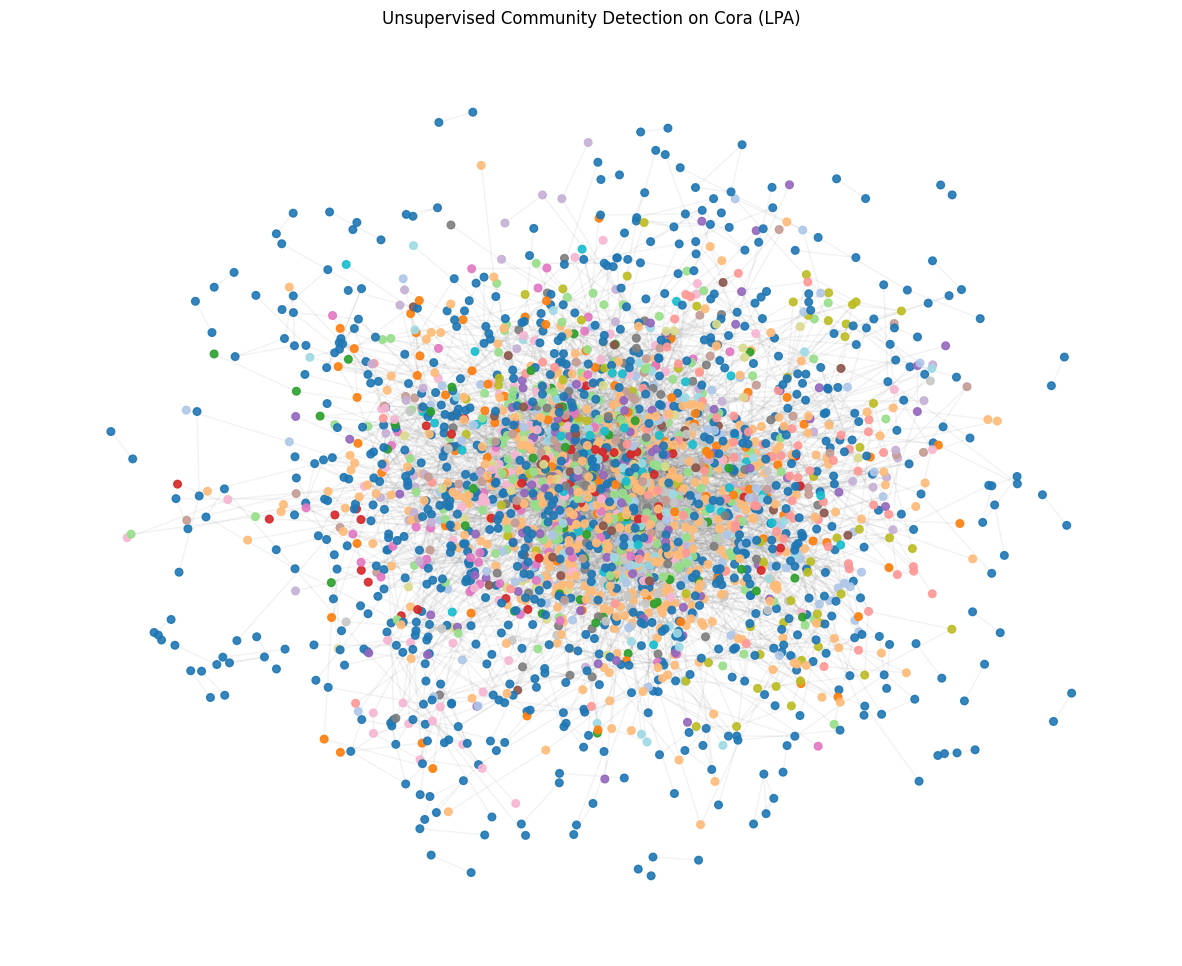

In [7]:
# 1. Setup Layout (This takes a moment for 2k nodes)
print("Calculating layout...")
pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

# 2. Map Communities to Colors
# We only color the major communities distinctly, others gray
unique_comms = list(major_communities)
import matplotlib.cm as cm

# Create a color list
node_colors = []
for node in G.nodes():
    label = G.nodes[node]['community']
    if label in unique_comms:
        # Assign a color based on the label index
        node_colors.append(unique_comms.index(label))
    else:
        # Tiny communities get a generic color
        node_colors.append(-1)

# 3. Draw
plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(
    G, pos, 
    node_size=30, 
    node_color=node_colors, 
    cmap=plt.cm.tab20, # A colormap with many distinct colors
    alpha=0.9
)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

plt.title("Unsupervised Community Detection on Cora (LPA)")
plt.axis('off')
plt.show()

In [8]:
# Let's look at the largest found community
largest_comm_id = communities.most_common(1)[0][0]
nodes_in_largest = [n for n, attr in G.nodes(data=True) if attr['community'] == largest_comm_id]

# What are the actual topics of papers in this community?
topics_in_cluster = [G.nodes[n]['ground_truth'] for n in nodes_in_largest if 'ground_truth' in G.nodes[n]]
topic_counts = Counter(topics_in_cluster)

print(f"Analysis of Largest Discovered Cluster (ID: {largest_comm_id})")
print(f"Dominant Topics in this cluster:")
for topic, count in topic_counts.most_common(5):
    print(f"  {topic}: {count} papers")

print("\n(If one topic dominates, the algorithm successfully found a coherent subject group purely from citations!)")

Analysis of Largest Discovered Cluster (ID: 35)
Dominant Topics in this cluster:
  Genetic_Algorithms: 315 papers
  Reinforcement_Learning: 11 papers
  Neural_Networks: 11 papers
  Case_Based: 6 papers
  Theory: 5 papers

(If one topic dominates, the algorithm successfully found a coherent subject group purely from citations!)


# Analysis of Discovered Communities
The results above reveal a strong correlation between the structural communities found by the algorithm and the actual semantic topics of the papers. By examining the composition of the largest discovered community (Cluster 35), we can evaluate the algorithm's unsupervised performance.

## Cluster 35 Composition:

- Genetic_Algorithms: 315 papers (Dominant)
- Reinforcement_Learning: 11 papers
- Neural_Networks: 11 papers
- Case_Based: 6 papers
- Theory: 5 papers

## 1. High Purity and Coherence
The algorithm successfully isolated the "Genetic Algorithms" field with approximately 90.5% purity (315 out of 348 papers). This is a significant result given that the algorithm had access only to the graph structure (citations) and no textual content. It demonstrates that the citation patterns within this sub-field are highly internal, creating a dense "natural" community that the Label Propagation Algorithm could easily detect.

## 2. Semantic Relevance of "Noise"
The non-dominant papers in this cluster—primarily Reinforcement Learning and Neural Networks—are not random misclassifications. In machine learning literature, genetic algorithms are frequently applied to optimize neural networks or used as alternative search strategies in reinforcement learning. The inclusion of these papers suggests that the algorithm correctly identified "bridge" papers or interdisciplinary work that sits on the boundary of the Genetic Algorithms community, rather than failing to distinguish unrelated topics.

## 3. Structural Homophily
The visualization confirms that while the network is dense (the central "hairball" structure typical of citation networks), the underlying data supports the existence of distinct, separable groups. The algorithm effectively leveraged the homophily in the network—where papers tend to cite other papers in the same field—to partition the graph into meaningful scientific subjects.